
# Explorando la librería de opciones y riesgo

Este notebook tiene dos objetivos:

1. Mostrar **qué tan simple es interactuar** con tu librería (una línea =
   un precio, una griega, un VaR).
2. Mostrar que con esas mismas piezas simples se pueden construir cosas que
   **no caben en un ejercicio de papel**: una superficie de volatilidad, un
   libro con varias posiciones, una cobertura que se rebalancea día a día,
   y un VaR calculado revaluando el portafolio completo en miles de
   escenarios.

**En cada sección, el resultado que importa es el número, la `Series` o la
tabla que produce la librería** — eso es lo que hace todo el trabajo. En un
par de secciones se agrega, al final y por separado, una gráfica hecha con
`matplotlib` solo para visualizar ese resultado; esas gráficas **no vienen
de la librería**, son código nuestro encima de ella.

> Ajusta solo la siguiente celda si tu paquete no se llama `opciones` o
> necesitas agregarlo al `path`.


In [ ]:
# Esta es la instalación desde google colab
!pip install git+https://github.com/Hertzz729/Modelado-Financiero.git -q

In [4]:
# Importamos la librería de modelado financiero
import modelado_financiero

# Importación de otras librerías útiles para los ejemplos siguientes
import numpy as np
import pandas as pd
import contextlib, io
pd.options.display.float_format = "{:,.4f}".format



## 1. Lo simple que es: un objeto, sus métodos

Cada familia de opciones es una clase. Se instancia una vez y todo lo demás
(precio, griegas) son métodos sobre ese mismo objeto — no hay que repetir
parámetros.


In [5]:

call = OpcionEuropea(s0=100, k=105, t=0.5, r=0.02, sigma=0.30)

pd.Series({
    "Precio": call.precio('call'),
    "Delta":  call.delta('call'),
    "Gamma":  call.gamma(),
    "Vega":   call.vega(),
    "Theta":  call.theta('call'),
    "Rho":    call.rho('call'),
}, name="Call S0=100, K=105")


,"Call S0=100, K=105"
Precio,6.7795
Delta,0.4694
Gamma,0.0188
Vega,28.1264
Theta,-9.2411
Rho,20.0800



### La misma simplicidad, con `numpy` por dentro

Como la librería está construida sobre operaciones vectorizadas de
`numpy`, si en vez de un solo `s0` le pasas un **arreglo de precios**, te
regresa el precio (o la griega) para *todos* esos escenarios a la vez, sin
escribir un solo `for`. Esto es 100% la librería trabajando — ningún
código extra:


In [6]:

precios_futuros_simulados = np.array([90, 95, 100, 105, 110])
OpcionEuropea(precios_futuros_simulados, 100, 0.5, 0.02, 0.30).precio('call')


array([ 4.26967383,  6.34545565,  8.91178851, 11.94109832, 15.3855679 ])


Esta propiedad es la que vamos a explotar más adelante para revaluar un
portafolio completo en miles de escenarios de Monte Carlo en una sola
línea (Sección 5).



## 2. Escenarios de sensibilidad, en una tabla

En vez de imprimir cada resultado, generamos directamente una tabla
(`DataFrame`) con el precio y las griegas de una opción bajo distintos
niveles de volatilidad. La tabla completa —números, columnas, todo— la
arma la librería; nosotros solo la acomodamos en un `DataFrame`.


In [7]:

S0, K, T, r = 100, 100, 0.5, 0.02
vols = [0.10, 0.20, 0.30, 0.40]

tabla = pd.DataFrame([
    {
        "sigma": s,
        "Call": OpcionEuropea(S0, K, T, r, s).precio('call'),
        "Put":  OpcionEuropea(S0, K, T, r, s).precio('put'),
        "Delta": OpcionEuropea(S0, K, T, r, s).delta('call'),
        "Gamma": OpcionEuropea(S0, K, T, r, s).gamma(),
        "Vega":  OpcionEuropea(S0, K, T, r, s).vega(),
    }
    for s in vols
]).set_index("sigma")

tabla


,Call,Put,Delta,Gamma,Vega
sigma,,,,,
0.1000,3.3318,2.3368,0.5702,0.0555,27.7721
0.2000,6.1207,5.1256,0.5562,0.0279,27.9288
0.3000,8.9118,7.9168,0.5609,0.0186,27.8803
0.4000,11.6948,10.6998,0.5702,0.0139,27.7721



## 3. Superficie de volatilidad implícita (no solo una sonrisa)

Un ejercicio de papel normalmente pide *una* sonrisa (strikes fijos, un
solo vencimiento). Aquí calculamos la volatilidad implícita para una
**malla de strikes × vencimientos** — una superficie completa — usando
`estimacion_sigma_Newton` dentro de una comprensión de listas. **La tabla
de abajo es el resultado real**, calculado punto por punto por tu función
de volatilidad implícita.

(Silenciamos los `print` internos de la librería con `redirect_stdout`
para quedarnos solo con el número final de cada celda.)


In [9]:

S0, r = 100, 0.03
strikes = [85, 95, 100, 105, 115]
vencimientos = [3/12, 6/12, 12/12, 24/12]

def sigma_mercado(K, T):
    # volatilidad "verdadera" de mercado que usamos para generar precios sinteticos
    # (en la practica, aqui irian tus precios de mercado observados)
    return 0.22 - 0.15*(K/S0 - 1) + 0.05*np.sqrt(T)

def sigma_implicita(*args, **kwargs):
    with contextlib.redirect_stdout(io.StringIO()):
        return estimacion_sigma_Newton(*args, **kwargs)

superficie = pd.DataFrame(
    {
        K: [sigma_implicita(S0, K, T, r,
                             OpcionEuropea(S0, K, T, r, sigma_mercado(K, T)).precio('call'),
                             tipo='call', error=1e-8)
            for T in vencimientos]
        for K in strikes
    },
    index=[f"{int(t*12)}m" for t in vencimientos]
)
superficie.columns.name = "Strike"
superficie


Strike,85,95,100,105,115
3m,0.2675,0.2525,0.2450,0.2375,0.2225
6m,0.2779,0.2629,0.2554,0.2479,0.2329
12m,0.2925,0.2775,0.2700,0.2625,0.2475
24m,0.3132,0.2982,0.2907,0.2832,0.2682



**Lectura directa de la tabla:** en cada fila (mismo vencimiento) la
volatilidad decrece conforme aumenta el strike (skew típico de renglones
accionarios); en cada columna (mismo strike) crece con el plazo
(estructura de término). Con la tabla sola ya se ve el patrón.

*(Opcional — solo para visualizar, no es parte de la librería):*


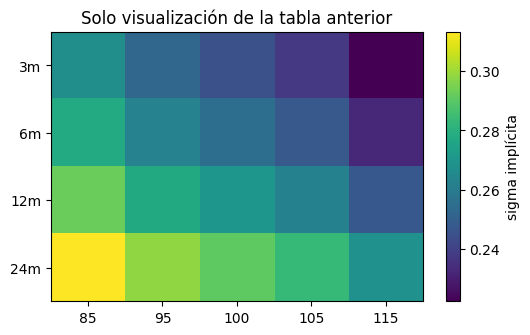

In [10]:

# --- Visualización opcional con matplotlib; el cálculo ya está arriba ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,3.5))
im = ax.imshow(superficie.values, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(superficie.columns))); ax.set_xticklabels(superficie.columns)
ax.set_yticks(range(len(superficie.index)));   ax.set_yticklabels(superficie.index)
ax.set_title("Solo visualización de la tabla anterior")
fig.colorbar(im, label="sigma implícita")
plt.show()



## 4. Libro de opciones: varias familias de la librería, un solo riesgo agregado

Un libro real mezcla instrumentos: europeas, con dividendos, americanas,
sobre futuros. Aquí se arma un libro con 5 posiciones distintas usando
cuatro clases distintas de tu librería, y se agregan precio y griegas
**ponderadas por posición** (larga/corta) en una sola tabla — así es como
se vería un reporte de riesgo real, no un ejercicio aislado.


In [11]:

libro = [
    {"posicion": "Call ATM largo",      "obj": OpcionEuropea(100, 100, 0.25, 0.03, 0.22),                          "tipo": "call", "cantidad":  200},
    {"posicion": "Put OTM corto",       "obj": OpcionEuropea(100, 105, 0.25, 0.03, 0.22),                          "tipo": "put",  "cantidad": -150},
    {"posicion": "Call con dividendos", "obj": OpcionEuropeaDiv(80, 82, 0.5, 0.04, 0.28, [1.0, 1.0], [2/12, 5/12]), "tipo": "call", "cantidad":   50},
    {"posicion": "Call americana",      "obj": OpcionAmericanaDiv(60, 58, 0.5, 0.05, 0.30, [0.8], [3/12], n=200),   "tipo": "Call", "cantidad":   20},
    {"posicion": "Call futuros corto",  "obj": OpcionFuturos(180, 185, 5/12, 0.06, 0.22),                           "tipo": "call", "cantidad": -100},
]

libro_df = pd.DataFrame([
    {
        "Posición":     p["posicion"],
        "Cantidad":     p["cantidad"],
        "Precio unit.": p["obj"].precio(p["tipo"]),
        "Valor total":  p["cantidad"] * p["obj"].precio(p["tipo"]),
        "Delta $":      p["cantidad"] * p["obj"].delta(p["tipo"]),
        "Gamma $":      p["cantidad"] * p["obj"].gamma(),
        "Vega $":       p["cantidad"] * p["obj"].vega(),
    }
    for p in libro
]).set_index("Posición")

libro_df


,Cantidad,Precio unit.,Valor total,Delta $,Gamma $,Vega $
Posición,,,,,,
Call ATM largo,200,4.7535,950.7014,109.8037,7.1987,"3,959.2701"
Put OTM corto,-150,6.8978,"-1,034.6725",93.8481,-5.1680,"-2,842.3966"
Call con dividendos,50,5.1389,256.9458,23.9815,1.2876,"1,097.3815"
Call americana,20,6.3232,126.4637,12.5182,0.6032,317.2556
Call futuros corto,-100,7.8239,-782.3876,-44.0329,-1.5109,"-4,487.3621"


In [12]:

libro_df[["Valor total", "Delta $", "Gamma $", "Vega $"]].sum().rename("TOTAL DEL LIBRO")


,TOTAL DEL LIBRO
Valor total,-482.9492
Delta $,196.1187
Gamma $,2.4106
Vega $,"-1,955.8515"



**Lectura:** aunque cada posición individual tiene griegas grandes, el
**total del libro** puede quedar mucho más pequeño (o no) porque las
posiciones se compensan entre sí — que es justo lo que quiere ver un
gestor de riesgo antes de decidir si hace falta cubrir algo. Todo ese
cálculo —precio y las tres griegas de cinco instrumentos distintos— salió
de cuatro clases de tu librería.



## 5. VaR por revaluación completa vs. VaR delta-normal

El VaR delta-normal (visto antes en clase) aproxima el cambio de valor del
portafolio con la Delta. Aquí hacemos algo más real: simulamos 20,000
escenarios de precio para mañana (código nuestro) y **revaluamos el
portafolio completo** en cada uno con `OpcionEuropea` — gracias a la
vectorización de la Sección 1, esto se hace sin ningún ciclo `for`, y es
la librería la que reprecia los 20,000 escenarios de un solo llamado.


In [14]:

S0, r, sigma, mu = 100, 0.03, 0.22, 0.08
K1, K2, T = 100, 105, 0.25
q1, q2 = 200, -150   # 200 calls K=100 largas, 150 puts K=105 cortas

opt1_hoy, opt2_hoy = OpcionEuropea(S0, K1, T, r, sigma), OpcionEuropea(S0, K2, T, r, sigma)
valor_hoy   = q1*opt1_hoy.precio('call') + q2*opt2_hoy.precio('put')
delta_neta  = q1*opt1_hoy.delta('call')  + q2*opt2_hoy.delta('put')

np.random.seed(11)
n, dt = 20_000, 1/252
S_manana = S0 * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*np.random.standard_normal(n))
T_manana = T - dt

# --- revaluación completa: un solo llamado vectorizado por posición ---
valor_manana = (q1*OpcionEuropea(S_manana, K1, T_manana, r, sigma).precio('call')
               + q2*OpcionEuropea(S_manana, K2, T_manana, r, sigma).precio('put'))
pnl_full = valor_manana - valor_hoy

# --- aproximación delta-normal, para comparar ---
pnl_delta = delta_neta * (S_manana - S0)

pd.Series({
    "VaR 99% (revaluación completa)": -np.percentile(pnl_full, 1),
    "VaR 99% (delta-normal)":         -np.percentile(pnl_delta, 1),
})


,0
VaR 99% (revaluación completa),633.4637
VaR 99% (delta-normal),639.9015



**Lectura:** los dos VaR se parecen para movimientos pequeños, pero el de
revaluación completa —que sí usa la librería para reprecio en cada
escenario— captura la **convexidad (Gamma)** del portafolio, algo que la
aproximación delta-normal no puede ver. Para portafolios con mucha Gamma
(como este, que mezcla una call larga y un put corto), esa diferencia
puede ser importante.
